# Analyse Exploratoire des Données (EDA)

In [411]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuration
plt.style.use('default')
sns.set_palette("husl")

## 1. Finance Report

In [412]:
import pandas as pd

In [413]:
finance_report = pd.read_excel('data/finance-report-042024.xlsx', sheet_name='Transaction Journal', skiprows=2, index_col=0)
finance_report.head()

,PR/HR No.,Report No.,Category (optional),Transaction Reference,Transaction Date,Reporting Month,Description,2nd Description (Recipent),Activity Code,Budget Line Code,Transaction Amount,Currency,EX rate,Total Amount In USD,Charging%,InforEuro Rate USD to EUR,Net / Reporting Amount,Payment Status,Invoice Date
1,B 00240,1st Report,HR Field,1.0,2024-02-29,yyyy02,February Salary-24 - Person A - Dialysis Techn...,Person A,1.0,1.1.1,12476.0000,TRY,31.19,400.00,1.0,0.922,368.80000,Bank Payment,NaT
2,B 00240,1st Report,HR Field,2.0,2024-02-29,yyyy02,Transfer fees for February Salary-24 - Person...,PTT,4.0,4.10.,124.7600,TRY,31.19,4.00,1.0,0.922,3.68800,Bank Payment,NaT
3,B 03763,1st Report,HR Field,3.0,2024-02-29,yyyy02,February Salary-24 - Huseın Ahmad Jabran- Dial...,Huseın Ahmad Jabran,1.0,1.1.1,12476.0000,TRY,31.19,400.00,1.0,0.922,368.80000,Bank Payment,NaT
4,B 03763,1st Report,HR Field,4.0,2024-02-29,yyyy02,Transfer fees for February Salary-24 - Huseın ...,PTT,4.0,4.10.,124.7600,TRY,31.19,4.00,1.0,0.922,3.68800,Bank Payment,NaT
5,B 00304,1st Report,HR Field,5.0,2024-02-29,yyyy02,February Salary-24 -Husam Aldin Nader Al Shawi...,Husam Aldin Nader Al Shawi,1.0,1.1.1,10396.5627,TRY,31.19,333.33,1.0,0.922,307.33026,Bank Payment,NaT


In [414]:
finance_report.info()

<class 'pandas.core.frame.DataFrame'>
Index: 161 entries, 1 to 161
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   PR/HR No.                   158 non-null    object        
 1   Report No.                  158 non-null    object        
 2   Category (optional)         158 non-null    object        
 3   Transaction Reference       47 non-null     float64       
 4   Transaction Date            161 non-null    datetime64[ns]
 5   Reporting Month             161 non-null    object        
 6   Description                 161 non-null    object        
 7   2nd Description (Recipent)  158 non-null    object        
 8   Activity Code               158 non-null    float64       
 9   Budget Line Code            158 non-null    object        
 10  Transaction Amount          158 non-null    float64       
 11  Currency                    161 non-null    object        
 12 

In [415]:
finance_report.describe()

,Transaction Reference,Transaction Date,Activity Code,Transaction Amount,EX rate,Total Amount In USD,Charging%,InforEuro Rate USD to EUR,Net / Reporting Amount,Invoice Date
count,47.00000,161,158.000000,158.000000,161.000000,161.000000,161.000000,161.000000,161.000000,28
mean,23.93617,2024-04-04 04:37:16.024844800,2.094937,23824.198746,19.738533,824.822452,0.729193,0.923685,498.724768,2024-04-08 12:00:00
min,1.00000,2024-02-29 00:00:00,1.000000,0.600000,1.000000,0.000000,0.100000,0.921230,0.000000,2024-02-22 00:00:00
25%,12.50000,2024-02-29 00:00:00,1.000000,83.330000,1.000000,4.833332,0.250000,0.921230,3.700800,2024-04-07 00:00:00
50%,24.00000,2024-03-31 00:00:00,1.000000,645.945000,31.190000,274.816189,1.000000,0.922000,163.978940,2024-04-16 00:00:00
75%,35.50000,2024-04-30 00:00:00,4.000000,20273.500000,32.050000,866.054230,1.000000,0.922000,368.800000,2024-04-25 00:00:00
max,45.00000,2024-04-30 00:00:00,4.000000,780266.400000,32.511100,24000.000000,1.000000,1.000000,22109.520000,2024-04-27 00:00:00
std,13.60691,NaN,1.431172,76529.703104,15.076496,2331.509317,0.352649,0.010643,2073.134363,NaN


In [416]:
missing = finance_report.isnull().sum()
missing[missing > 0]

PR/HR No.                       3
Report No.                      3
Category (optional)             3
Transaction Reference         114
2nd Description (Recipent)      3
Activity Code                   3
Budget Line Code                3
Transaction Amount              3
Invoice Date                  133
dtype: int64

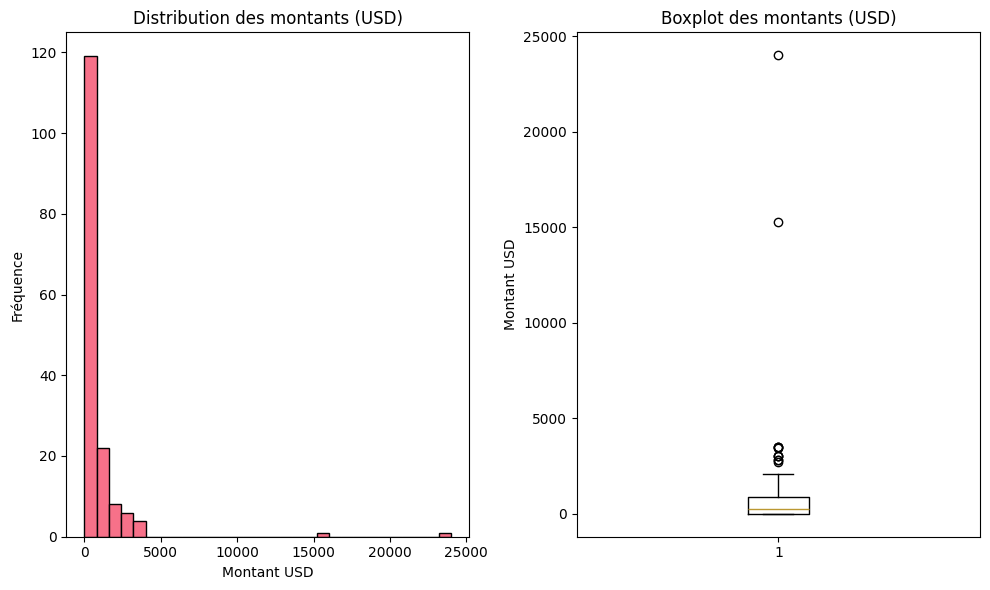

In [417]:
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.hist(finance_report[' Total Amount In USD'].dropna(), bins=30, edgecolor='black')
plt.title('Distribution des montants (USD)')
plt.xlabel('Montant USD')
plt.ylabel('Fréquence')

plt.subplot(1, 2, 2)
plt.boxplot(finance_report[' Total Amount In USD'].dropna())
plt.title('Boxplot des montants (USD)')
plt.ylabel('Montant USD')

plt.tight_layout()
plt.show()

#### Comment:
**Histogram:**\
The majority of transactions are for amounts less than approximately 5000 USD, with rare bars around 15000 USD and 24000 USD. This indicates that small transactions dominate, which is common, while fraud often hides in high anomalies.
The rare bars suggest potential outliers to investigate, for example via columns such as Velocity Score.

**Boxplot:**\
The box is very low (low median), with short whiskers, confirming the concentration of low values. The outliers are suspicious and could indicate fraud.
The interquartile range is narrow, indicating low variability for most values.

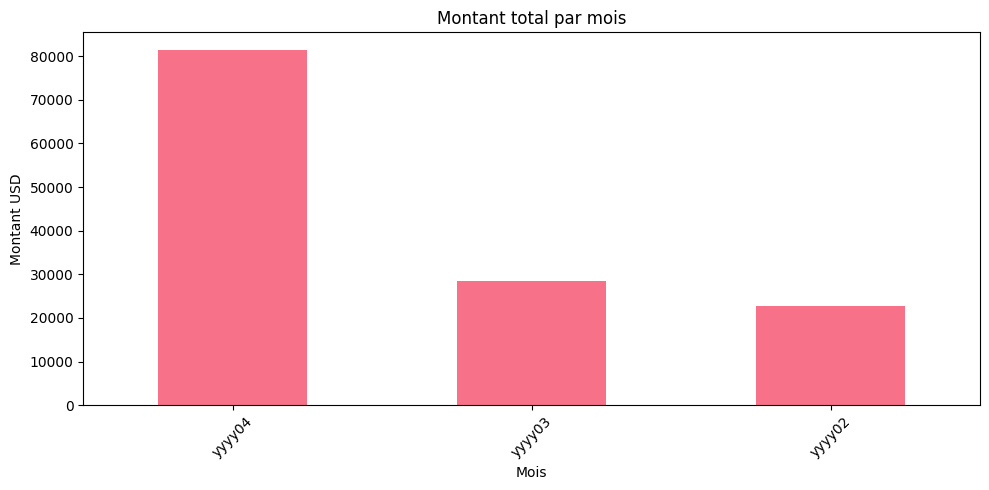

In [418]:
monthly = finance_report.groupby('Reporting Month')[' Total Amount In USD'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
monthly.plot(kind='bar')
plt.title('Montant total par mois')
plt.xlabel('Mois')
plt.ylabel('Montant USD')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

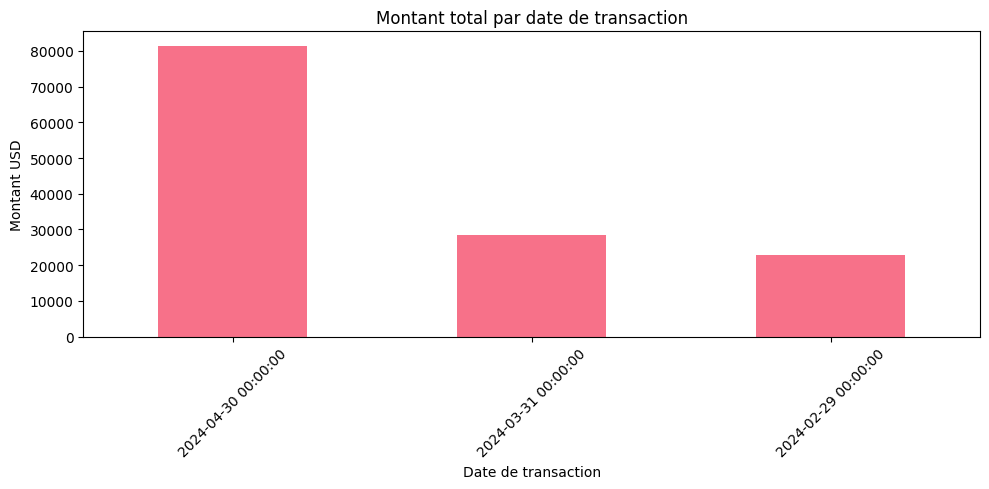

In [419]:
monthly_transac = finance_report.groupby('Transaction Date')[' Total Amount In USD'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
monthly_transac.plot(kind='bar')
plt.title('Montant total par date de transaction')
plt.xlabel('Date de transaction')
plt.ylabel('Montant USD')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Comment
**2024-04-20** : approximately USD 80,000 (same scale as monthly above), surge in suspicious activity.\
**2024-05-30 et 2024-09-30** : approximately USD 30,000, consistent with a stable post-peak trend.

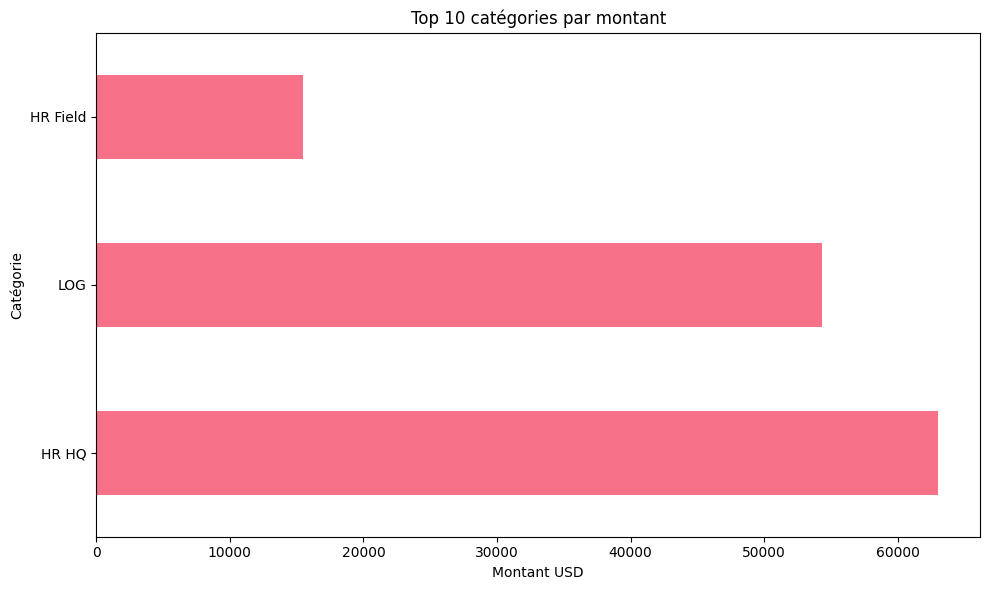

In [420]:
category_total = finance_report.groupby('Category (optional)')[' Total Amount In USD'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
category_total.plot(kind='barh')
plt.title('Top 10 catégories par montant')
plt.xlabel('Montant USD')
plt.ylabel('Catégorie')
plt.tight_layout()
plt.show()

#### Comment
**HR concentration**: approximately 70% of funds in HR/HR-HO, suggesting budget priorities in these categories.\
**Fraud link**: Dominant categories often hide anomalies; we can perhaps cross-reference with Activity Code, 2nd Description (recipients) and Relative deviation for suspects.

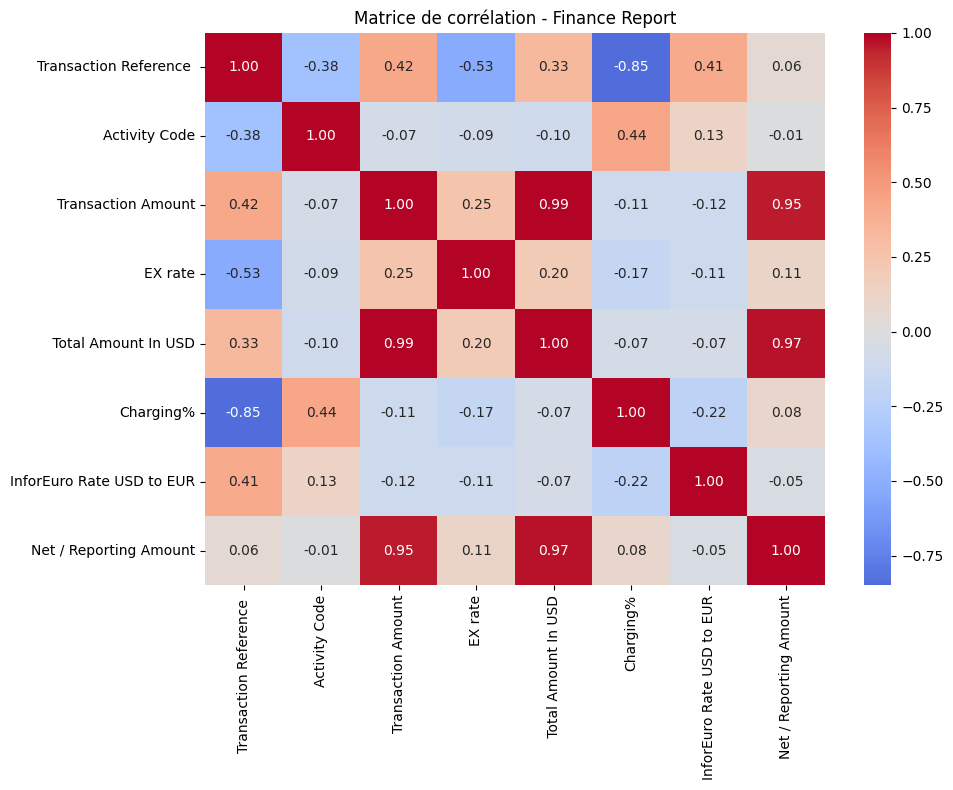

In [421]:
numeric_cols = finance_report.select_dtypes(include=[np.number]).columns
correlation_matrix = finance_report[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matrice de corrélation - Finance Report')
plt.tight_layout()
plt.show()

#### Comment
Strong correlation (>0.7):
- Avg Total Amount / Total Amount USD / Transaction Amount => historical average linked to current
- Net/Reporting / Charging% => Direct accounting link (percentage net impact) 

Moderate signals (0.3-0.7):
- EX rate / Transaction amount => moderate exchange rate effect

Strong correlations are generally due to direct links of a computational nature.

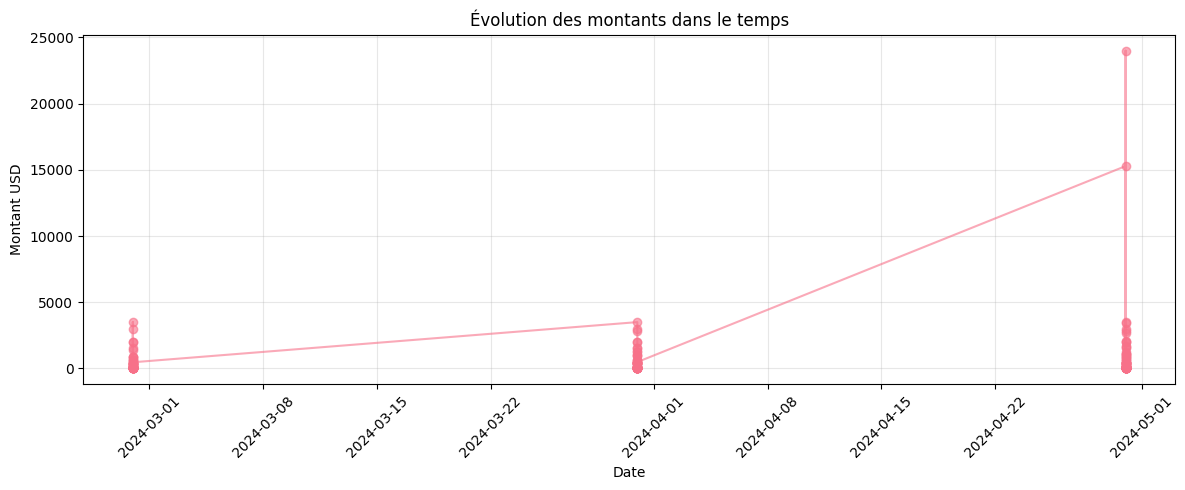

In [422]:
finance_report_sorted = finance_report.sort_values('Transaction Date')
plt.figure(figsize=(12, 5))
plt.plot(finance_report_sorted['Transaction Date'], finance_report_sorted[' Total Amount In USD'], marker='o', linestyle='-', alpha=0.6)
plt.title('Évolution des montants dans le temps')
plt.xlabel('Date')
plt.ylabel('Montant USD')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Comment
Clustering by date: we see three "clusters" of points around a few days (early March, early April, early May), so the dataset is not continuous over time but rather event-driven (one-off extractions or incomplete reporting).\
On each date, there are many amounts close to 0–5k and a few higher values. In May, one or two amounts skyrocket (around 15k and then around 24k).

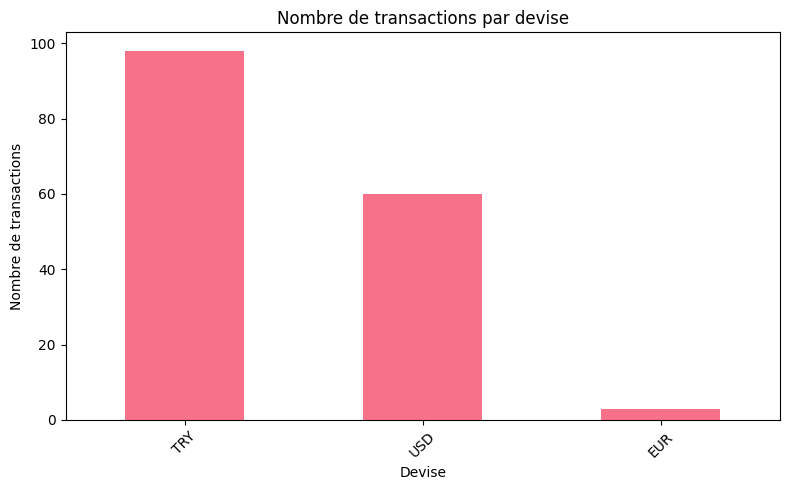

In [423]:
currency_counts = finance_report['Currency'].value_counts()
plt.figure(figsize=(8, 5))
currency_counts.plot(kind='bar')
plt.title('Nombre de transactions par devise')
plt.xlabel('Devise')
plt.ylabel('Nombre de transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Comment

The majority is in TRY, followed by USD, and very little in EUR. In other words, the dataset is mainly "driven" by one main currency, which directly influences the amounts converted into USD and the importance of the exchange rate.

For fraud analysis, outliers must be checked for each currency: a "suspicious" threshold is not necessarily the same in TRY vs USD, even after conversion, if the exchange rate varies significantly.

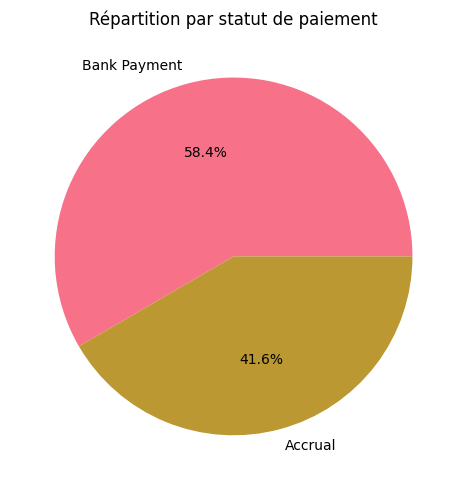

In [424]:
payment_status = finance_report['Payment Status'].value_counts()
plt.figure(figsize=(8, 5))
payment_status.plot(kind='pie', autopct='%1.1f%%')
plt.title('Répartition par statut de paiement')
plt.ylabel('')
plt.tight_layout()
plt.show()

#### Comment
- Bank Payment (58.4%): transactions actually paid via bank, therefore more "real" in terms of cash.
- Accrual (41.6%): commitment entries, potentially linked to invoices/expenses to be attached, therefore sometimes without immediate payment.

Perhaps analyse fraud only on one status.

## 2. Solidarity Syria Budget

#### Transactions List sheet

In [425]:
solidarity_syria = pd.read_excel('data/Updated_SENED_Budget_Solidarity_Syria-Turkey_2023_05_17_EN.xlsx', sheet_name='Transactions List', skiprows=3, index_col=0)
solidarity_syria.head()

,Budget,REF,no. of vouch-er,Internal voucher number of the\nRecipient,Date of \nvoucher,Name of the Recipient\nfrom voucher/evidence,Reason for payment\n(detailled content of voucher/evidence),Currency \nof voucher,Amount \nof voucher\n,Exchange rate\n(according EU currency converter or exchange of funds),Expenditure in the currency of Grant Agreement\n\n€,Unnamed: 12,Year,Period,Unnamed: 15
No,,,,,,,,,,,,,,,
1.0,1.1.08,S2400800388,F09683,Social Security,2024-08-31 00:00:00,MOHAMMAD YASSER MALATI,MOHAMMAD YASSER MALATI/ Social Security Augu...,TRY,13363.84,0.02792,373.118413,NaN,2024.0,8.0,0.0
2.0,1.1.08,S2400800388,F09696,Income Tax & Stamp,2024-08-31 00:00:00,MOHAMMAD YASSER MALATI,MOHAMMAD YASSER MALATI/ Income Tax & Stamp T...,TRY,4149.53,0.02792,115.854878,NaN,2024.0,8.0,0.0
3.0,1.1.08,S2400800388,F09216,Salary,2024-08-31 00:00:00,MOHAMMAD YASSER MALATI,MOHAMMAD YASSER MALATI/ Bank Paid Net Salary...,TRY,24113.53,0.02792,673.249758,NaN,2024.0,8.0,1.0
4.0,1.1.08,S2400900388,F07182,Social Security,2024-09-30 00:00:00,MOHAMMAD YASSER MALATI,MOHAMMAD YASSER MALATI/ Social Security Sept...,TRY,13466.64,0.02646,356.327294,NaN,2024.0,9.0,0.0
5.0,1.1.08,S2400900388,F08575,Salary,2024-09-30 00:00:00,MOHAMMAD YASSER MALATI,MOHAMMAD YASSER MALATI/ Bank Paid Net Salary...,TRY,32702.31,0.02646,865.303123,NaN,2024.0,9.0,0.0


In [426]:
solidarity_syria.info()

<class 'pandas.core.frame.DataFrame'>
Index: 320 entries, 1.0 to nan
Data columns (total 15 columns):
 #   Column                                                                Non-Null Count  Dtype  
---  ------                                                                --------------  -----  
 0   Budget                                                                318 non-null    object 
 1   REF                                                                   318 non-null    object 
 2   no. of vouch-er                                                       317 non-null    object 
 3   Internal voucher number of the
Recipient                              318 non-null    object 
 4   Date of 
voucher                                                      318 non-null    object 
 5   Name of the Recipient
from voucher/evidence                           318 non-null    object 
 6   Reason for payment
(detailled content of voucher/evidence)            318 non-null    object 
 7   Cu

In [427]:
solidarity_syria.describe()

,Amount \nof voucher\n,Exchange rate\n(according EU currency converter or exchange of funds),Expenditure in the currency of Grant Agreement\n\n€,Unnamed: 12,Year,Period,Unnamed: 15
count,318.000000,318.000000,320.000000,0.0,318.000000,318.000000,318.000000
mean,3309.530098,0.597330,626.852510,NaN,2024.452830,6.440252,0.031447
std,7616.171174,0.442222,5636.004264,NaN,0.498555,4.597477,0.174796
min,-251.690000,0.026220,-6.762910,NaN,2024.000000,1.000000,0.000000
25%,5.179125,0.027110,4.742950,NaN,2024.000000,2.000000,0.000000
50%,350.000000,0.901880,88.655070,NaN,2024.000000,9.000000,0.000000
75%,2760.000000,0.957490,361.404641,NaN,2025.000000,11.000000,0.000000
max,45512.720000,0.961260,100296.401531,NaN,2025.000000,12.000000,1.000000


In [428]:
missing_syria = solidarity_syria.isnull().sum()
missing_syria[missing_syria > 0]

Budget                                                                     2
REF                                                                        2
no. of vouch-er                                                            3
Internal voucher number of the\nRecipient                                  2
Date of \nvoucher                                                          2
Name of the Recipient\nfrom voucher/evidence                               2
Reason for payment\n(detailled content of voucher/evidence)                2
Currency \nof voucher                                                      2
Amount \nof voucher\n                                                      2
Exchange rate\n(according EU currency converter or exchange of funds)      2
Unnamed: 12                                                              320
Year                                                                       2
Period                                                                     2

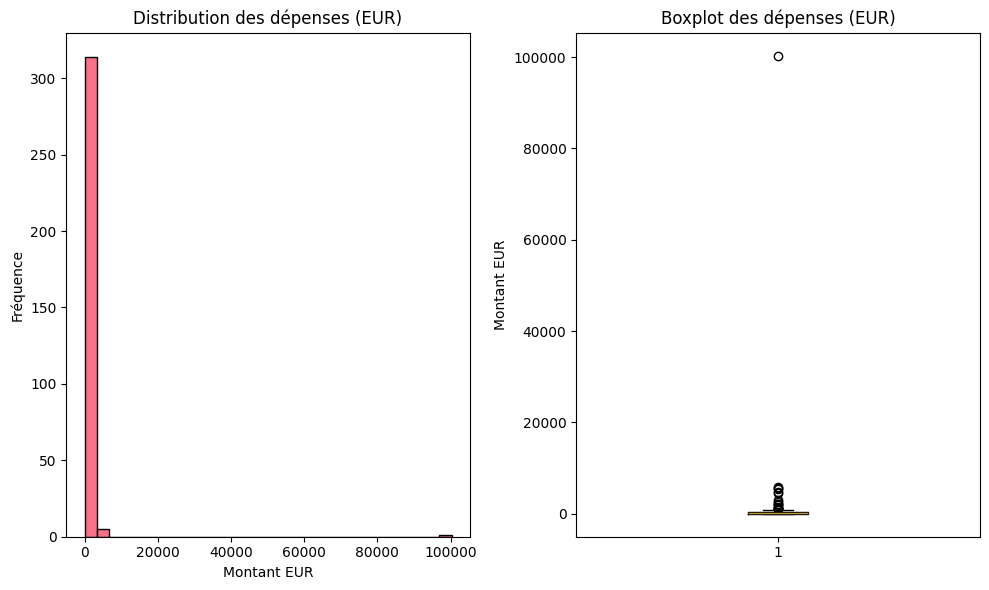

In [429]:
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.hist(solidarity_syria['Expenditure in the currency of Grant Agreement\n\n€'].dropna(), bins=30, edgecolor='black')
plt.title('Distribution des dépenses (EUR)')
plt.xlabel('Montant EUR')
plt.ylabel('Fréquence')

plt.subplot(1, 2, 2)
plt.boxplot(solidarity_syria['Expenditure in the currency of Grant Agreement\n\n€'].dropna())
plt.title('Boxplot des dépenses (EUR)')
plt.ylabel('Montant EUR')

plt.tight_layout()
plt.show()

#### Comment
Both graphs show a highly skewed distribution: a large number of small expenditures and a few extremely high expenditures dominating the scale. The box plot confirms the presence of major outliers (up to around EUR 100k) and numerous "intermediate" outliers (a few thousand).

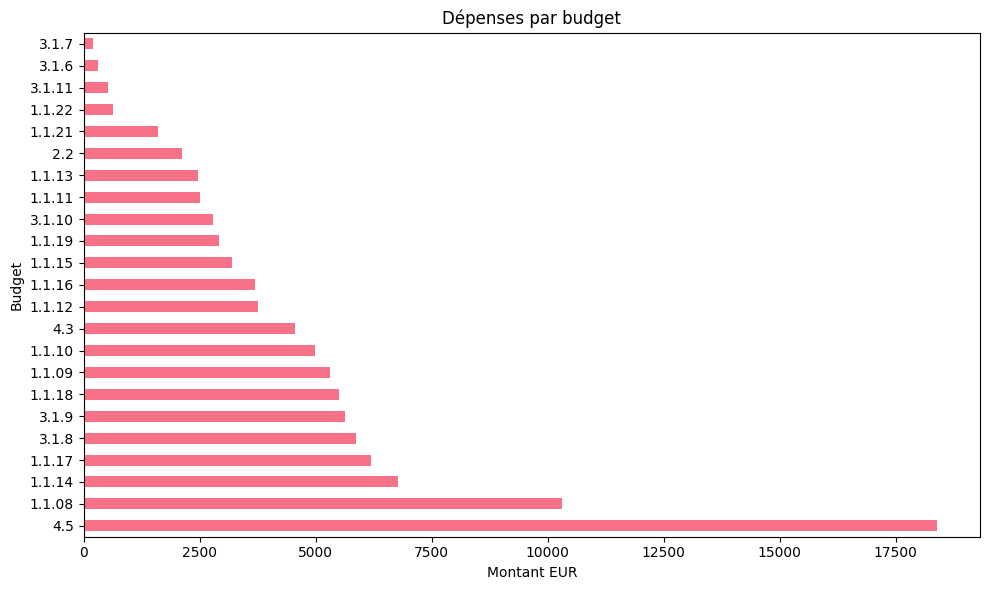

In [430]:
budget_total = solidarity_syria.groupby('Budget')['Expenditure in the currency of Grant Agreement\n\n€'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
budget_total.plot(kind='barh')
plt.title('Dépenses par budget')
plt.xlabel('Montant EUR')
plt.ylabel('Budget')
plt.tight_layout()
plt.show()

#### Comment
The graph highlights a high concentration of expenditure on a few budgets, with one budget (4.5) dominating significantly.

Budget concentration: a few budget lines account for most of the expenditure. This is a classic scenario, but it is also a good starting point for the audit (top budgets = potentially where anomalies have the greatest impact).

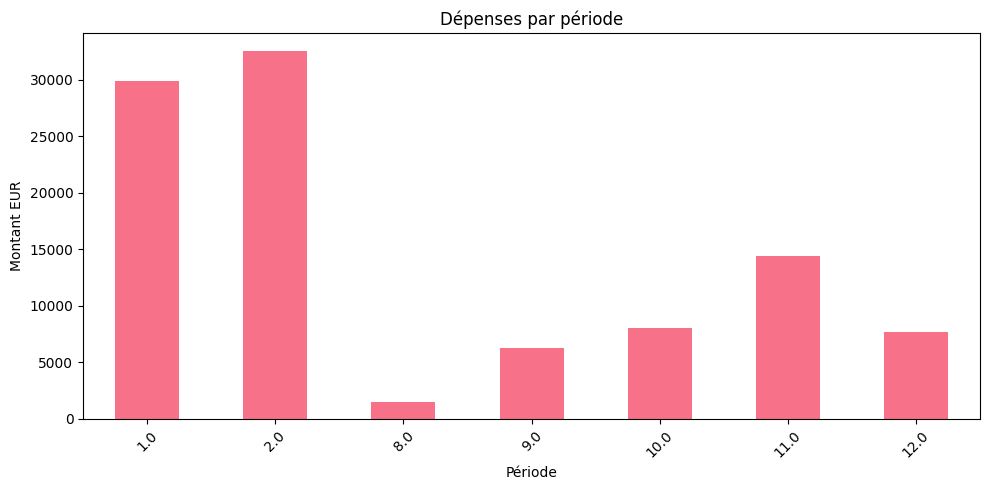

In [431]:
period_total = solidarity_syria.groupby('Period')['Expenditure in the currency of Grant Agreement\n\n€'].sum().sort_index()
plt.figure(figsize=(10, 5))
period_total.plot(kind='bar')
plt.title('Dépenses par période')
plt.xlabel('Période')
plt.ylabel('Montant EUR')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Comment
Periods 1 and 2: major peaks (~30k and ~35k EUR), meaning that a large portion of the budget is used up very early on (or within the first two periods observed).\
Period 8: almost nothing (~1–2k), which could be an "empty" month, a period without activity, or a data gap.\
Periods 9–12: recovery (≈6k, 8k, 14–15k, 7–8k), with a secondary maximum in period 11.

In [432]:
print("=== Finance Report ===")
print(f"Nombre total de transactions: {len(finance_report)}")
print(f"Montant total (USD): ${finance_report[' Total Amount In USD'].sum():,.2f}")
print(f"Montant moyen (USD): ${finance_report[' Total Amount In USD'].mean():,.2f}")
print(f"Montant médian (USD): ${finance_report[' Total Amount In USD'].median():,.2f}")
print()
print("=== Solidarity Syria ===")
print(f"Nombre total de transactions: {len(solidarity_syria)}")
montants = solidarity_syria['Expenditure in the currency of Grant Agreement\n\n€']
print(f"Nombre total de transactions: {len(solidarity_syria)}")
print(f"Montant total (EUR): €{montants.sum():,.2f}")
print(f"Montant moyen (EUR): €{montants.mean():,.2f}")
print(f"Montant médian (EUR): €{montants.median():,.2f}")

=== Finance Report ===
Nombre total de transactions: 161
Montant total (USD): $132,796.41
Montant moyen (USD): $824.82
Montant médian (USD): $274.82

=== Solidarity Syria ===
Nombre total de transactions: 320
Nombre total de transactions: 320
Montant total (EUR): €200,592.80
Montant moyen (EUR): €626.85
Montant médian (EUR): €88.66


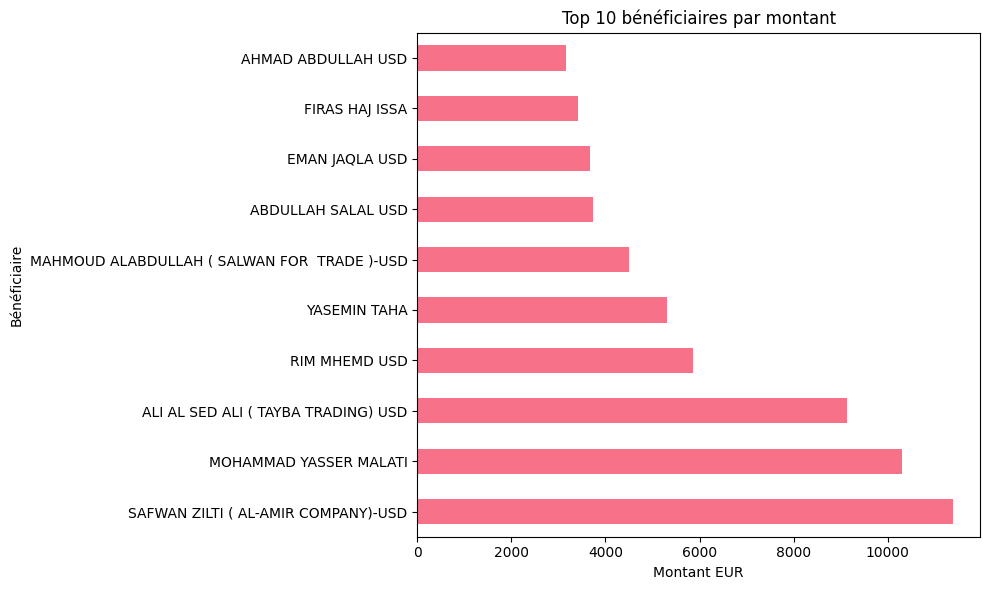

In [433]:
recipients = solidarity_syria.groupby('Name of the Recipient\nfrom voucher/evidence')['Expenditure in the currency of Grant Agreement\n\n€'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
recipients.plot(kind='barh')
plt.title('Top 10 bénéficiaires par montant')
plt.xlabel('Montant EUR')
plt.ylabel('Bénéficiaire')
plt.tight_layout()
plt.show()

#### Comment
- Pareto effect/concentration: this is typical in expenditure (a few recurring suppliers). In auditing/fraud, these top beneficiaries are a priority because an anomaly in their accounts has a greater impact on the total.
- Risk of duplication/standardisation: if the same beneficiary appears in several variations (e.g. "ALI AL SED ALI..." vs "ALI ALSed Ali", or with/without "USD"), there is a risk of underestimating its concentration. Cleaning (stripping, uppercasing, removing "USD" suffixes, standardising spaces) can change the top 10.

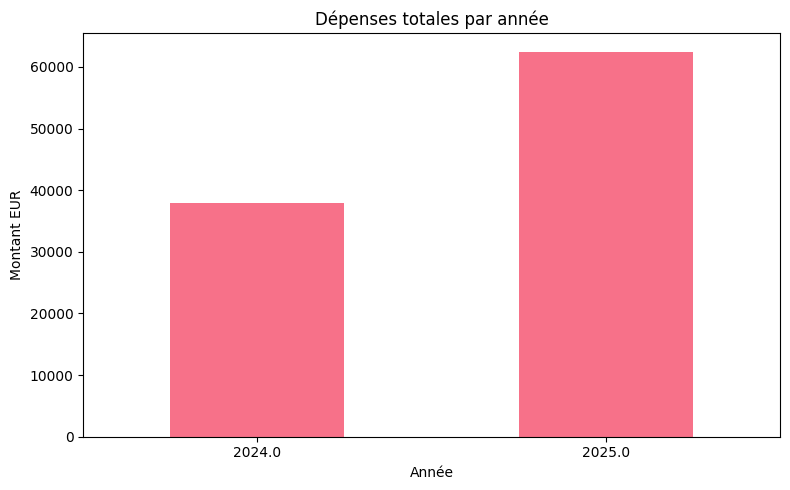

In [434]:
year_total = solidarity_syria.groupby('Year')['Expenditure in the currency of Grant Agreement\n\n€'].sum().sort_index()
plt.figure(figsize=(8, 5))
year_total.plot(kind='bar')
plt.title('Dépenses totales par année')
plt.xlabel('Année')
plt.ylabel('Montant EUR')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Comment
Increase in activity: higher expenditure in 2025 may result from a higher volume of accounting documents, higher unit amounts, or both.

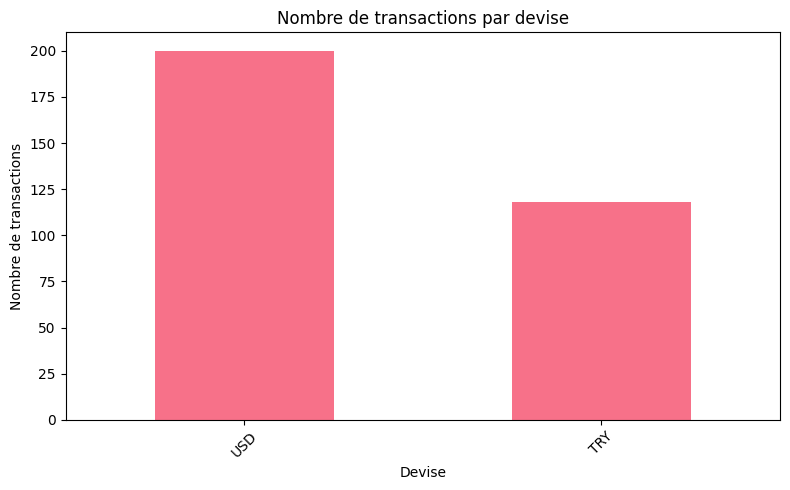

In [435]:
currency_syria = solidarity_syria['Currency \nof voucher'].value_counts()
plt.figure(figsize=(8, 5))
currency_syria.plot(kind='bar')
plt.title('Nombre de transactions par devise')
plt.xlabel('Devise')
plt.ylabel('Nombre de transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Comment
- USD dominance: analyses based on amounts in EUR remain relevant, but the majority of original amounts are in foreign currencies, so the exchange rate is an important factor in variability.
- Two sub-populations: USD and TRY may have very different distributions of amounts and rates, and mixing the two can create false outliers (e.g. large TRY amount + unfavourable rate).

## Dataset Restructuring

#### 1. Datasets from the Amendment EUR Sheet (SENED_Budget_Solidarity_Syria-Turkey file)

In [436]:
file = "data/Updated_SENED_Budget_Solidarity_Syria-Turkey_2023_05_17_EN.xlsx"

- Extraction and restructuring of the `Human Resources Allocation Dataset` and export of it into dataframes

In [437]:
def restructure_df1(df):
    import pandas as pd
    import numpy as np
    import re
    
    df = df.copy()

    # ---------------------------------------------------
    # 0) Remove the first three non-data rows from Excel
    #    (these rows contain metadata, titles, merged cells, etc.)
    # ---------------------------------------------------
    df = df.iloc[3:].reset_index(drop=True)

    # The next row becomes the header row
    df.columns = df.iloc[0]

    # Remove the header row from the data
    df = df[1:].reset_index(drop=True)

    # ---------------------------------------------------
    # 1) Basic cleanup of column names
    #    (remove extra spaces and normalize formatting)
    # ---------------------------------------------------
    df.columns = df.columns.astype(str).str.replace(r'\s+', ' ', regex=True).str.strip()

    # ---------------------------------------------------
    # 2) Keep only the first six structural columns:
    #    code | description | unit | number_of_units | unit_cost_eur | total_cost_eur
    # ---------------------------------------------------
    core = df.iloc[:, :6].copy()
    core.columns = [
        "code",
        "description",
        "unit",
        "number_of_units",
        "unit_cost_eur",
        "total_cost_eur"
    ]

    # ---------------------------------------------------
    # 3) Remove repeated internal header rows
    #    (these appear frequently in poorly formatted Excel exports)
    # ---------------------------------------------------
    header_like = [
        "Expenditure related to the project Recommendations",
        "Unit",
        "Number of units",
        "Unit cost in EUR",
        "Total cost in EUR",
        "Unit cost (euros)",
        "Total cost (euros)"
    ]
    core["description"] = core["description"].astype(str).str.replace(r'\s+', ' ', regex=True).str.strip()
    core = core[~core["description"].isin(header_like)]

    # ---------------------------------------------------
    # 4) Keep only valid budget lines:
    #    code must match pattern like 1.1.01
    # ---------------------------------------------------
    code_pat = re.compile(r"^\d+\.\d+\.\d+$")
    core["code"] = core["code"].astype(str).str.strip()
    core = core[core["code"].apply(lambda x: bool(code_pat.match(x)))]

    # ---------------------------------------------------
    # 5) Numeric cleanup:
    #    convert values to numeric (handle commas, spaces, € symbol)
    # ---------------------------------------------------
    def to_num(s):
        if pd.isna(s):
            return np.nan
        s = str(s).strip()
        s = s.replace("\xa0", " ")   # non-breaking space
        s = s.replace(" ", "")
        s = s.replace(",", ".")
        s = re.sub(r"[^0-9\.\-]", "", s)
        return pd.to_numeric(s, errors="coerce")

    core["number_of_units"] = core["number_of_units"].apply(to_num)
    core["unit_cost_eur"]   = core["unit_cost_eur"].apply(to_num)
    core["total_cost_eur"]  = core["total_cost_eur"].apply(to_num)

    # ---------------------------------------------------
    # 6) Automatically compute total cost when missing:
    #    total_cost = number_of_units * unit_cost_eur
    # ---------------------------------------------------
    mask = (
        core["total_cost_eur"].isna() &
        core["number_of_units"].notna() &
        core["unit_cost_eur"].notna()
    )
    core.loc[mask, "total_cost_eur"] = (
        core["number_of_units"] * core["unit_cost_eur"]
    )

    # ---------------------------------------------------
    # 7) Final cleanup of description text
    # ---------------------------------------------------
    core["description"] = (
        core["description"]
        .astype(str)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
        .replace({"nan": np.nan, "None": np.nan})
    )

    # ---------------------------------------------------
    # 8) Drop fully empty rows (if any)
    # ---------------------------------------------------
    core = core.dropna(how="all")

    # ---------------------------------------------------
    # 9) Reset clean row indexing
    # ---------------------------------------------------
    core = core.reset_index(drop=True)

    return core

df1 = pd.read_excel(file, skiprows=0, nrows=31, header=None)
df1_structured = restructure_df1(df1)
df1_structured

,code,description,unit,number_of_units,unit_cost_eur,total_cost_eur
0,1.1.01,IT and Media Officer (50%) TR,per month,6,1650,9900.0
1,1.1.02,MHPSS Technical Specialist (10%) TR,per month,6,3500,21000.0
2,1.1.03,Supply Chain Coordinator (10%) TR,per month,6,3100,18600.0
3,1.1.04,Project Coordinator (10%) TR,per month,6,3100,18600.0
4,1.1.05,Inclusion Technical Specialist (10%) SY,per month,6,850,5100.0
5,1.1.06,MEAL Coordinator (10%) TR,per month,6,3100,18600.0
6,1.1.07,HR Coordinator (10%) TR,per month,6,3100,18600.0
7,1.1.08,Finance Coordiantor (10%) TR,per month,6,3100,18600.0
8,1.1.08,Project Officer (100%) TR,per month,5,1650,8250.0
9,1.1.09,Finance Assistant (100%) TR,per month,5,800,4000.0


- Extraction and restructuring of the `Travel costs Dataset` and export of it into dataframes

In [438]:
import pandas as pd
import numpy as np
import re

def restructure_df2(df):
    """
    Restructure the second dataframe extracted from the Excel file.
    This function cleans columns, standardizes textual fields, 
    converts numerical values, filters valid cost lines (2.1, 2.2, 2.3),
    and recalculates totals when needed.
    """
    
    df = df.copy()

    # -----------------------------------------------------------
    # 1) Extract only the 6 relevant columns
    #    These correspond to:
    #    - code
    #    - description
    #    - unit
    #    - number_of_units
    #    - unit_cost
    #    - total_cost
    #    We ignore column names since many are 'Unnamed'.
    # -----------------------------------------------------------
    core = df.iloc[:, :6].copy()
    core.columns = ["code", "description", "unit", "number_of_units", "unit_cost", "total_cost"]

    # -----------------------------------------------------------
    # 2) Minimal text cleaning for string columns
    #    - replace multiple spaces
    #    - remove trailing/leading spaces
    # -----------------------------------------------------------
    for c in ["code", "description", "unit"]:
        core[c] = (
            core[c].astype(str)
                    .str.replace(r"\s+", " ", regex=True)
                    .str.strip()
        )

    # -----------------------------------------------------------
    # 3) Keep only valid cost lines:
    #    pattern: "digit . digit"  → example: 2.1, 2.2, 2.3
    # -----------------------------------------------------------
    code_pattern = re.compile(r"^\d+\.\d+$")
    core = core[core["code"].apply(lambda x: bool(code_pattern.match(x)))]

    # -----------------------------------------------------------
    # 4) Robust numeric conversion:
    #    - remove non-numeric characters
    #    - replace comma with dot
    #    - remove non-breaking spaces
    # -----------------------------------------------------------
    def to_num(val):
        if pd.isna(val):
            return np.nan
        s = str(val).strip()
        s = s.replace("\xa0", " ")  # non‑breaking space
        s = s.replace(" ", "")
        s = s.replace(",", ".")
        s = re.sub(r"[^0-9\.\-]", "", s)
        return pd.to_numeric(s, errors="coerce")

    core["number_of_units"] = core["number_of_units"].apply(to_num)
    core["unit_cost"]       = core["unit_cost"].apply(to_num)
    core["total_cost"]      = core["total_cost"].apply(to_num)

    # -----------------------------------------------------------
    # 5) Recompute total_cost when:
    #    - total_cost is missing
    #    - number_of_units and unit_cost are available
    # -----------------------------------------------------------
    need_total = (
        core["total_cost"].isna() &
        core["number_of_units"].notna() &
        core["unit_cost"].notna()
    )

    core.loc[need_total, "total_cost"] = (
        core.loc[need_total, "number_of_units"] *
        core.loc[need_total, "unit_cost"]
    )

    # -----------------------------------------------------------
    # 6) Keep only expected lines (2.1, 2.2, 2.3)
    # -----------------------------------------------------------
    core = core.sort_values("code").head(3).reset_index(drop=True)

    return core

# Example usage
df2 = pd.read_excel(file, skiprows=38, nrows=4)
df2_structured = restructure_df2(df2)
df2_structured

,code,description,unit,number_of_units,unit_cost,total_cost
0,2.1,2 Cars for mobile team and benfiaries,per month,2.0,6000.0,12000.0
1,2.2,Fuel for 2 cars,per month,5.0,200.0,1000.0
2,2.3,Travel cost from Turkey to Syria for managemen...,per month,5.0,200.0,1000.0


- Extraction and restructuring of the `Material and supplies Dataset` and export of it into dataframes

In [439]:
import pandas as pd
import numpy as np
import re 


def extract_df3_section(df, section="3.1.", sub_min=1, sub_max=11, verbose=False):
    """
    Extracts a specific section (e.g., '3.1.') from df3, where Excel rows contain merged cells,
    inconsistent headers, and mixed numeric/text fields.
    
    The function dynamically identifies:
        - code             (e.g., 3.1.1 — wherever it appears in the row)
        - description      (text between code and unit)
        - unit             (matched among a known set of units)
        - number_of_units  (first numeric value after unit)
        - unit_cost        (second numeric value after unit)
        - total_cost       (last significant numeric value of the row)

    Handles:
        - decimal commas
        - currency symbols (€)
        - merged headers drifting into the first row
        - 'Unnamed' columns
        - sub‑totals and total lines
        - normalizes '3.14' into '3.1.14' if required
    """
    df = df.copy()

    # -----------------------------------------------------------
    # 0) If the first data row accidentally became column headers,
    #    detect codes inside column names and push them back into df.
    # -----------------------------------------------------------
    code_any_pat = re.compile(r"^\d+\.\d+(\.\d+)?$")
    if any(code_any_pat.match(str(c).strip()) for c in df.columns):
        header_as_row = pd.DataFrame([list(df.columns)], columns=df.columns)
        df = pd.concat([header_as_row, df], ignore_index=True)
        df.columns = range(df.shape[1])  # reset columns to numeric positions

    # -----------------------------------------------------------
    # Helper sets & functions
    # -----------------------------------------------------------
    unit_set = {
        "per item", "per month", "per day", "per week", "per year",
        "lumpsum", "per beneficiary", "per person", "per service",
        "per unit", "per hour"
    }

    def normalize_code(x: str) -> str:
        """
        Converts:
            '3.14'     -> '3.1.14'
            '3.1.10'   -> unchanged
        Only modifies 2‑level patterns.
        """
        s = str(x).strip()
        if re.match(r"^\d+\.\d+\.\d+$", s):
            return s
        m = re.match(r"^(\d+)\.(\d+)$", s)
        if m:
            a, bc = m.groups()
            try:
                return f"{a}.1.{int(bc)}"
            except:
                return s
        return s

    def to_num(val):
        """
        Robust numeric conversion:
        - removes € / spaces / non‑breaking spaces
        - converts decimal commas to dots
        """
        if pd.isna(val):
            return np.nan
        s = str(val).replace("\xa0", " ").replace("€", "")
        s = s.replace(" ", "").replace(",", ".")
        s = re.sub(r"[^0-9\.\-]", "", s)
        return pd.to_numeric(s, errors="coerce")

    def is_texty(x):
        """
        Detect textual description fields and avoid misclassifying
        numeric‑looking strings (e.g., '750,00') as text.
        """
        if pd.isna(x):
            return False
        s = str(x).strip()
        if s == "" or s.lower() in {"nan", "none"}:
            return False
        # If composed only of digits, spaces, commas, dots → numeric
        if re.match(r"^[\d\.\,\s]+$", s):
            return False
        return True

    # -----------------------------------------------------------
    # 1) Row‑by‑row extraction of codes, description, units, numbers
    # -----------------------------------------------------------
    rows = []

    for ridx in df.index:
        row = df.iloc[ridx, :].tolist()

        # --- Detect code anywhere in the row ---
        code = None
        code_col_idx = None
        for j, val in enumerate(row):
            sv = str(val).strip()
            if re.match(r"^\d+\.\d+(\.\d+)?$", sv):
                code = normalize_code(sv)
                code_col_idx = j
                break
        if not code:
            continue

        # --- Keep only codes in the desired section (3.1.X) ---
        if not code.startswith(section):
            continue

        # Extract the final index (X)
        try:
            sub = int(code.split(".")[-1])
        except:
            continue

        if not (sub_min <= sub <= sub_max):
            continue

        # --- Skip subtotal/total lines ---
        row_join = " ".join(str(x) for x in row if pd.notna(x)).lower()
        if "sub-total" in row_join or "subtotal" in row_join:
            continue

        # -----------------------------------------------------------
        # Extract description and unit
        # -----------------------------------------------------------
        description_parts = []
        unit = None
        unit_idx = None

        for j in range(code_col_idx + 1, len(row)):
            cell = row[j]
            s = str(cell).strip()

            # Found a unit?
            if s.lower() in unit_set:
                unit = s
                unit_idx = j
                break

            # Text description candidate
            if is_texty(cell):
                description_parts.append(s)

        description = " ".join(description_parts).strip() if description_parts else np.nan

        # Skip lines whose description *is* a subtotal
        if isinstance(description, str) and description.lower().startswith(("sub-total", "subtotal")):
            continue

        # -----------------------------------------------------------
        # Extract numeric values (number_of_units, unit_cost, total_cost)
        # -----------------------------------------------------------
        start_scan = (unit_idx + 1) if unit_idx is not None else (code_col_idx + 1)

        numeric_values = []
        for j in range(start_scan, len(row)):
            num = to_num(row[j])
            if pd.notna(num):
                numeric_values.append(num)

        # Heuristics
        number_of_units = np.nan
        unit_cost = np.nan
        total_cost = np.nan

        nonneg = [v for v in numeric_values if v >= 0]

        if len(nonneg) >= 1:
            number_of_units = nonneg[0]
        if len(nonneg) >= 2:
            unit_cost = nonneg[1]
        if len(nonneg) >= 1:
            total_cost = nonneg[-1]

        # Recalculate total if needed
        if pd.isna(total_cost) and pd.notna(number_of_units) and pd.notna(unit_cost):
            total_cost = number_of_units * unit_cost

        # Clean description
        if isinstance(description, str):
            description = re.sub(r"\s+", " ", description).strip()

        rows.append({
            "code": code,
            "description": description,
            "unit": unit,
            "number_of_units": number_of_units,
            "unit_cost": unit_cost,
            "total_cost": total_cost
        })

    # -----------------------------------------------------------
    # 2) Convert to dataframe and sort naturally (3.1.1 → 3.1.11)
    # -----------------------------------------------------------
    out = pd.DataFrame(rows)

    if not out.empty:
        out["__sub"] = out["code"].map(lambda c: int(str(c).split(".")[-1]))
        out = out.sort_values("__sub").drop(columns="__sub").reset_index(drop=True)

        # Final consistency check: recalc totals with tolerance
        ok = out["number_of_units"].notna() & out["unit_cost"].notna()
        expected = out.loc[ok, "number_of_units"] * out.loc[ok, "unit_cost"]

        delta = (out.loc[ok, "total_cost"] - expected).abs()
        fix = delta > (0.01 * expected.abs() + 1e-9)

        out.loc[ok & fix, "total_cost"] = expected[fix]

    if verbose:
        print(f"[extract_df3_section] Extracted rows: {len(out)}")

    return out


# Example usage:
df3 = pd.read_excel(file, skiprows=44, nrows=11)
df3_structured = extract_df3_section(df3, section="3.1.", sub_min=1, sub_max=11, verbose=True)
df3_structured

[extract_df3_section] Extracted rows: 10


,code,description,unit,number_of_units,unit_cost,total_cost
0,3.1.1,Laptops,per item,6.0,750.000000,4500.000000
1,3.1.2,Mobile phones,per item,6.0,350.000000,2100.000000
2,3.1.3,Projector,per item,1.0,600.000000,600.000000
3,3.1.4,Water dispenser,per item,2.0,200.000000,400.000000
4,3.1.6,Supplies and Stationary,lumpsum,1.0,400.000000,400.000000
5,3.1.7,Refreshment for activities,lumpsum,1.0,400.000000,400.000000
6,3.1.8,PSS Kits for chilren,lumpsum,1.0,7500.000000,7500.000000
7,3.1.9,PSS Kits for adults,lumpsum,1.0,7500.000000,7500.000000
8,3.1.10,Printing MEAL materials,lumpsum,6.0,84.848485,509.090909
9,3.1.11,Montessori tools,lumpsum,1.0,1000.000000,1000.000000


- Extraction and restructuring of the `other costs Dataset` and export of it into dataframes

In [440]:
import pandas as pd
import numpy as np
import re
import unicodedata
def extract_selected_costs(df):
    """
    Extracts cost lines for codes 4.2, 4.3 and 4.5 from df4,
    regardless of column position and with aggressive normalization
    to handle Excel artifacts (non-breaking spaces, narrow NBSP, trailing dots, etc.).
    """

    target_codes = {"4.2", "4.3", "4.5"}
    rows = []

    unit_set = {
        "per item","per month","per day","per week","per year",
        "lumpsum","per beneficiary","per person","per service",
        "per unit","per hour"
    }

    def to_num(x):
        """Robust numeric conversion handling €, NBSP, spaces, commas."""
        if pd.isna(x):
            return np.nan
        s = str(x)
        # unify spaces
        s = s.replace("\xa0", " ").replace("\u202f", " ")  # NBSP + narrow NBSP
        s = s.replace("€","").replace(" ", "")
        s = s.replace(",", ".")
        s = re.sub(r"[^0-9.\-]", "", s)
        return pd.to_numeric(s, errors="coerce")

    def norm_code_cell(x: object) -> str:
        """
        Normalize any cell that might contain a code like '4.2':
          - Unicode normalize (NFKC)
          - replace commas with dots
          - remove all whitespace including NBSP / narrow NBSP / zero-width
          - strip trailing dot (e.g., '4.2.' -> '4.2')
        """
        s = "" if pd.isna(x) else str(x)
        # Unicode normalization (handles odd punctuation/width)
        s = unicodedata.normalize("NFKC", s)
        # Remove zero-width chars
        s = s.replace("\u200b", "").replace("\ufeff", "")
        # Normalize spaces
        s = (s.replace("\xa0", " ")   # NBSP
               .replace("\u202f", " ") # narrow NBSP
               .replace("\u2007", " "))# figure space
        s = s.strip()
        # Replace comma with dot
        s = s.replace(",", ".")
        # Remove ALL inner whitespace
        s = re.sub(r"\s+", "", s)
        # Drop a trailing dot if present ('4.2.' -> '4.2')
        s = s[:-1] if s.endswith(".") else s
        return s

    # Accept '4.2', '4.3', '4.5'
    code_pattern = re.compile(r"^\d+\.\d+$")

    for i in df.index:
        row = df.iloc[i, :].tolist()

        # 1) Find first TARGET code in the row (scan all columns)
        code = None
        code_idx = None
        for j, cell in enumerate(row):
            cell_str = norm_code_cell(cell)
            if code_pattern.match(cell_str) and cell_str in target_codes:
                code = cell_str
                code_idx = j
                break  # stop only when a TARGET code is found

        if not code:
            continue  # skip if none of the targeted codes in this row

        # 2) Extract description and unit (to the right of the code cell)
        description_parts = []
        unit = None
        unit_idx = None
        for j in range(code_idx + 1, len(row)):
            s_raw = row[j]
            s = "" if pd.isna(s_raw) else str(s_raw).strip()
            if s.lower() in unit_set:
                unit = s
                unit_idx = j
                break
            # keep only non numeric-like text chunks
            if s and not re.match(r"^[0-9.,\s€]+$", s):
                description_parts.append(s)

        description = re.sub(r"\s+", " ", " ".join(description_parts)).strip() if description_parts else ""

        # 3) Numbers after unit
        if unit_idx is not None:
            n_units   = to_num(row[unit_idx + 1]) if unit_idx + 1 < len(row) else np.nan
            unit_cost = to_num(row[unit_idx + 2]) if unit_idx + 2 < len(row) else np.nan
            total_cost = to_num(row[unit_idx + 3]) if unit_idx + 3 < len(row) else np.nan
        else:
            n_units = unit_cost = total_cost = np.nan

        # Auto-calc total if missing
        if pd.isna(total_cost) and pd.notna(n_units) and pd.notna(unit_cost):
            total_cost = n_units * unit_cost

        rows.append({
            "code": code,
            "description": description,
            "unit": unit,
            "number_of_units": n_units,
            "unit_cost": unit_cost,
            "total_cost": total_cost
        })

    out = pd.DataFrame(rows)
    if not out.empty:
        out = out.sort_values("code").reset_index(drop=True)
    return out

df4 = pd.read_excel(file, skiprows=57, nrows=4)
df4_structured = extract_selected_costs(df4)

df4_structured

,code,description,unit,number_of_units,unit_cost,total_cost
0,4.3,Office running cost A'zaz with Mobile bills fo...,per month,6.0,183.333333,1100.0
1,4.5,ECF,per beneficiary,350.0,50.000000,17500.0


#### 2. Dataset from the Transactions List Sheet (SENED_Budget_Solidarity_Syria-Turkey file)

In [441]:
solidarity_syria = pd.read_excel('data/Updated_SENED_Budget_Solidarity_Syria-Turkey_2023_05_17_EN.xlsx', sheet_name='Transactions List', skiprows=3, index_col=0)
solidarity_syria.head()

,Budget,REF,no. of vouch-er,Internal voucher number of the\nRecipient,Date of \nvoucher,Name of the Recipient\nfrom voucher/evidence,Reason for payment\n(detailled content of voucher/evidence),Currency \nof voucher,Amount \nof voucher\n,Exchange rate\n(according EU currency converter or exchange of funds),Expenditure in the currency of Grant Agreement\n\n€,Unnamed: 12,Year,Period,Unnamed: 15
No,,,,,,,,,,,,,,,
1.0,1.1.08,S2400800388,F09683,Social Security,2024-08-31 00:00:00,MOHAMMAD YASSER MALATI,MOHAMMAD YASSER MALATI/ Social Security Augu...,TRY,13363.84,0.02792,373.118413,NaN,2024.0,8.0,0.0
2.0,1.1.08,S2400800388,F09696,Income Tax & Stamp,2024-08-31 00:00:00,MOHAMMAD YASSER MALATI,MOHAMMAD YASSER MALATI/ Income Tax & Stamp T...,TRY,4149.53,0.02792,115.854878,NaN,2024.0,8.0,0.0
3.0,1.1.08,S2400800388,F09216,Salary,2024-08-31 00:00:00,MOHAMMAD YASSER MALATI,MOHAMMAD YASSER MALATI/ Bank Paid Net Salary...,TRY,24113.53,0.02792,673.249758,NaN,2024.0,8.0,1.0
4.0,1.1.08,S2400900388,F07182,Social Security,2024-09-30 00:00:00,MOHAMMAD YASSER MALATI,MOHAMMAD YASSER MALATI/ Social Security Sept...,TRY,13466.64,0.02646,356.327294,NaN,2024.0,9.0,0.0
5.0,1.1.08,S2400900388,F08575,Salary,2024-09-30 00:00:00,MOHAMMAD YASSER MALATI,MOHAMMAD YASSER MALATI/ Bank Paid Net Salary...,TRY,32702.31,0.02646,865.303123,NaN,2024.0,9.0,0.0


# Data cleaning

In [442]:
# ============================================
# DATA DIAGNOSTIC FUNCTION
# ============================================

def data_diagnostic(df, name="DataFrame"):
    print(f"\n{'='*50}")
    print(f"DIAGNOSTIC REPORT : {name}")
    print(f"{'='*50}")
    
    print(f"Shape : {df.shape}")
    
    print("\nNumber of duplicates :", df.duplicated().sum())
    
    print("\nMissing values per column :")
    print(df.isnull().sum())
    
    print("\nTotal missing values :", df.isnull().sum().sum())
    
    print("\nNumeric columns summary :")
    print(df.describe())

In [443]:
def remove_duplicates_verbose(df):
    before = df.shape[0]
    duplicates = df.duplicated().sum()
    
    print(f"\nDuplicates detected : {duplicates}")
    
    df = df.drop_duplicates()
    
    after = df.shape[0]
    print(f"Rows removed : {before - after}")
    
    return df

In [444]:
def handle_missing_verbose(df):
    print("\nMissing values BEFORE cleaning:")
    print(df.isnull().sum())
    
    total_before = df.isnull().sum().sum()
    print("Total NaN before:", total_before)
    
    # Remove fully empty rows
    df = df.dropna(how="all")
    
    # Fill numeric columns with median
    num_cols = df.select_dtypes(include="number").columns
    for col in num_cols:
        df[col] = df[col].fillna(df[col].median())
    
    total_after = df.isnull().sum().sum()
    
    print("\nMissing values AFTER cleaning:")
    print(df.isnull().sum())
    print("Total NaN after:", total_after)
    
    return df

In [445]:
# ============================================
# OUTLIER DETECTION (NO REMOVAL - FRAUD SAFE)
# ============================================

def detect_outliers_verbose(df):
    
    num_cols = df.select_dtypes(include="number").columns
    df["is_outlier"] = 0   # colonne flag
    
    print("\nOUTLIER DETECTION REPORT")
    print("-" * 40)
    
    total_outliers = 0
    
    for col in num_cols:
        
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        outliers_mask = (df[col] < lower) | (df[col] > upper)
        n_outliers = outliers_mask.sum()
        
        if n_outliers > 0:
            print(f"{col} → {n_outliers} outliers")
            
            df.loc[outliers_mask, "is_outlier"] = 1
            total_outliers += n_outliers
    
    print("-" * 40)
    print("Total detected outliers (not removed):", total_outliers)
    
    return df

In [446]:
def clean_text_columns(df):
    text_cols = df.select_dtypes(include="object").columns
    
    for col in text_cols:
        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .str.replace(r"\s+", " ", regex=True)
        )
    
    return df

In [447]:
def full_cleaning_pipeline_verbose(df, name="DataFrame"):
    
    print(f"\n\n{'#'*60}")
    print(f"CLEANING PROCESS : {name}")
    print(f"{'#'*60}")
    
    print("\n--- INITIAL STATE ---")
    data_diagnostic(df, name)
    
    # 1. Remove duplicates
    df = remove_duplicates_verbose(df)
    
    # 2. Clean text
    df = clean_text_columns(df)
    
    # 3. Convert numeric
    df = df.apply(lambda col: pd.to_numeric(col, errors='ignore'))
    
    # 4. Handle missing
    df = handle_missing_verbose(df)
    
    # 5. Detect outliers (NO removal)
    df = detect_outliers_verbose(df)
    
    print("\n--- FINAL STATE ---")
    data_diagnostic(df, name)
    
    return df

#### finance_report dataframe

In [448]:
finance_clean = full_cleaning_pipeline_verbose(finance_report, "Finance Report")



############################################################
CLEANING PROCESS : Finance Report
############################################################

--- INITIAL STATE ---

DIAGNOSTIC REPORT : Finance Report
Shape : (161, 19)

Number of duplicates : 0

Missing values per column :
PR/HR No.                       3
Report No.                      3
Category (optional)             3
Transaction Reference         114
Transaction Date                0
Reporting Month                 0
Description                     0
2nd Description (Recipent)      3
Activity Code                   3
Budget Line Code                3
Transaction Amount              3
Currency                        0
EX rate                         0
 Total Amount In USD            0
Charging%                       0
InforEuro Rate USD to EUR       0
Net / Reporting Amount          0
Payment Status                  0
Invoice Date                  133
dtype: int64

Total missing values : 268

Numeric columns summar

/var/folders/jc/0rdgc11d06dgm3sng453_7yr0000gn/T/ipykernel_6948/2147058126.py:17: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(lambda col: pd.to_numeric(col, errors='ignore'))


In [449]:
finance_clean

,PR/HR No.,Report No.,Category (optional),Transaction Reference,Transaction Date,Reporting Month,Description,2nd Description (Recipent),Activity Code,Budget Line Code,Transaction Amount,Currency,EX rate,Total Amount In USD,Charging%,InforEuro Rate USD to EUR,Net / Reporting Amount,Payment Status,Invoice Date,is_outlier
1,B 00240,1st Report,HR Field,1.0,1709164800000000000,yyyy02,February Salary-24 - Person A - Dialysis Techn...,Person A,1.0,1.1.1,12476.0000,TRY,31.1900,400.000000,1.0,0.92200,368.800000,Bank Payment,-9223372036854775808,1
2,B 00240,1st Report,HR Field,2.0,1709164800000000000,yyyy02,Transfer fees for February Salary-24 - Person ...,PTT,4.0,4.10.,124.7600,TRY,31.1900,4.000000,1.0,0.92200,3.688000,Bank Payment,-9223372036854775808,1
3,B 03763,1st Report,HR Field,3.0,1709164800000000000,yyyy02,February Salary-24 - Huseın Ahmad Jabran- Dial...,Huseın Ahmad Jabran,1.0,1.1.1,12476.0000,TRY,31.1900,400.000000,1.0,0.92200,368.800000,Bank Payment,-9223372036854775808,1
4,B 03763,1st Report,HR Field,4.0,1709164800000000000,yyyy02,Transfer fees for February Salary-24 - Huseın ...,PTT,4.0,4.10.,124.7600,TRY,31.1900,4.000000,1.0,0.92200,3.688000,Bank Payment,-9223372036854775808,1
5,B 00304,1st Report,HR Field,5.0,1709164800000000000,yyyy02,February Salary-24 -Husam Aldin Nader Al Shawi...,Husam Aldin Nader Al Shawi,1.0,1.1.1,10396.5627,TRY,31.1900,333.330000,1.0,0.92200,307.330260,Bank Payment,-9223372036854775808,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,B 04073,3rd Report,HR HQ,24.0,1714435200000000000,yyyy04,April Salary - 24 - Vaseem Bakır Senior Progra...,Vaseem Bakır,1.0,1.1.9,90465.4800,TRY,32.3091,2800.000000,0.5,0.92123,1289.722000,Bank Payment,-9223372036854775808,1
158,B 04073,3rd Report,HR HQ,24.0,1714435200000000000,yyyy04,April Sgk - 24 - Vaseem Bakır Senior Program O...,Vaseem Bakır,1.0,1.1.9,51198.6400,TRY,32.3091,1584.650764,0.5,0.92123,729.913912,Bank Payment,-9223372036854775808,1
159,B 04073,3rd Report,HR HQ,24.0,1714435200000000000,yyyy04,April Tax - 24 - Vaseem Bakır Senior Program O...,Vaseem Bakır,1.0,1.1.9,27851.7200,TRY,32.3091,862.039487,0.5,0.92123,397.068318,Bank Payment,-9223372036854775808,0
160,B 04073,3rd Report,HR HQ,24.0,1714435200000000000,yyyy04,April EOS Benefit - 24 - Vaseem Bakır Senior P...,Vaseem Bakır,1.0,1.1.9,83.3300,USD,1.0000,83.330000,0.5,0.92123,38.383048,Accrual,-9223372036854775808,0


#### solidarity_syria dataframe

In [450]:
syria_clean = full_cleaning_pipeline_verbose(solidarity_syria, "Solidarity Syria")



############################################################
CLEANING PROCESS : Solidarity Syria
############################################################

--- INITIAL STATE ---

DIAGNOSTIC REPORT : Solidarity Syria
Shape : (320, 15)

Number of duplicates : 0

Missing values per column :
Budget                                                                     2
REF                                                                        2
no. of vouch-er                                                            3
Internal voucher number of the\nRecipient                                  2
Date of \nvoucher                                                          2
Name of the Recipient\nfrom voucher/evidence                               2
Reason for payment\n(detailled content of voucher/evidence)                2
Currency \nof voucher                                                      2
Amount \nof voucher\n                                                      2
Exchange rate

/var/folders/jc/0rdgc11d06dgm3sng453_7yr0000gn/T/ipykernel_6948/2147058126.py:17: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(lambda col: pd.to_numeric(col, errors='ignore'))
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


#### Human Resources Allocation dataframe

In [451]:
df1_clean = full_cleaning_pipeline_verbose(df1_structured, "df1 - HR")



############################################################
CLEANING PROCESS : df1 - HR
############################################################

--- INITIAL STATE ---

DIAGNOSTIC REPORT : df1 - HR
Shape : (22, 6)

Number of duplicates : 0

Missing values per column :
code               0
description        0
unit               0
number_of_units    0
unit_cost_eur      0
total_cost_eur     0
dtype: int64

Total missing values : 0

Numeric columns summary :
       number_of_units  unit_cost_eur  total_cost_eur
count        22.000000      22.000000       22.000000
mean          6.954545    1343.181818     8318.181818
std           4.358651    1203.570626     7091.133724
min           5.000000     200.000000     1000.000000
25%           5.000000     500.000000     2687.500000
50%           5.500000     750.000000     5050.000000
75%           6.000000    2737.500000    16425.000000
max          20.000000    3500.000000    21000.000000

Duplicates detected : 0
Rows removed : 0

Mis

/var/folders/jc/0rdgc11d06dgm3sng453_7yr0000gn/T/ipykernel_6948/2147058126.py:17: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(lambda col: pd.to_numeric(col, errors='ignore'))


In [452]:
df1_clean

,code,description,unit,number_of_units,unit_cost_eur,total_cost_eur,is_outlier
0,1.1.01,IT and Media Officer (50%) TR,per month,6,1650,9900.0,0
1,1.1.02,MHPSS Technical Specialist (10%) TR,per month,6,3500,21000.0,0
2,1.1.03,Supply Chain Coordinator (10%) TR,per month,6,3100,18600.0,0
3,1.1.04,Project Coordinator (10%) TR,per month,6,3100,18600.0,0
4,1.1.05,Inclusion Technical Specialist (10%) SY,per month,6,850,5100.0,0
5,1.1.06,MEAL Coordinator (10%) TR,per month,6,3100,18600.0,0
6,1.1.07,HR Coordinator (10%) TR,per month,6,3100,18600.0,0
7,1.1.08,Finance Coordiantor (10%) TR,per month,6,3100,18600.0,0
8,1.1.08,Project Officer (100%) TR,per month,5,1650,8250.0,0
9,1.1.09,Finance Assistant (100%) TR,per month,5,800,4000.0,0


#### Travel costs dataframe

In [453]:
df2_clean = full_cleaning_pipeline_verbose(df2_structured, "df2 - Travel Cost")



############################################################
CLEANING PROCESS : df2 - Travel Cost
############################################################

--- INITIAL STATE ---

DIAGNOSTIC REPORT : df2 - Travel Cost
Shape : (3, 6)

Number of duplicates : 0

Missing values per column :
code               0
description        0
unit               0
number_of_units    0
unit_cost          0
total_cost         0
dtype: int64

Total missing values : 0

Numeric columns summary :
       number_of_units    unit_cost    total_cost
count         3.000000     3.000000      3.000000
mean          4.000000  2133.333333   4666.666667
std           1.732051  3348.631561   6350.852961
min           2.000000   200.000000   1000.000000
25%           3.500000   200.000000   1000.000000
50%           5.000000   200.000000   1000.000000
75%           5.000000  3100.000000   6500.000000
max           5.000000  6000.000000  12000.000000

Duplicates detected : 0
Rows removed : 0

Missing values BEFORE 

/var/folders/jc/0rdgc11d06dgm3sng453_7yr0000gn/T/ipykernel_6948/2147058126.py:17: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(lambda col: pd.to_numeric(col, errors='ignore'))


In [454]:
df2_clean 

,code,description,unit,number_of_units,unit_cost,total_cost,is_outlier
0,2.1,2 Cars for mobile team and benfiaries,per month,2.0,6000.0,12000.0,0
1,2.2,Fuel for 2 cars,per month,5.0,200.0,1000.0,0
2,2.3,Travel cost from Turkey to Syria for managemen...,per month,5.0,200.0,1000.0,0


#### Material and supplies dataframe

In [455]:
df3_clean = full_cleaning_pipeline_verbose(df3_structured, "df3 - Travel Cost Part 2")



############################################################
CLEANING PROCESS : df3 - Travel Cost Part 2
############################################################

--- INITIAL STATE ---

DIAGNOSTIC REPORT : df3 - Travel Cost Part 2
Shape : (10, 6)

Number of duplicates : 0

Missing values per column :
code               0
description        0
unit               0
number_of_units    0
unit_cost          0
total_cost         0
dtype: int64

Total missing values : 0

Numeric columns summary :
       number_of_units    unit_cost   total_cost
count        10.000000    10.000000    10.000000
mean          2.600000  1878.484848  2490.909091
std           2.366432  2974.430777  2929.028898
min           1.000000    84.848485   400.000000
25%           1.000000   362.500000   427.272727
50%           1.000000   500.000000   800.000000
75%           5.000000   937.500000  3900.000000
max           6.000000  7500.000000  7500.000000

Duplicates detected : 0
Rows removed : 0

Missing values B

/var/folders/jc/0rdgc11d06dgm3sng453_7yr0000gn/T/ipykernel_6948/2147058126.py:17: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(lambda col: pd.to_numeric(col, errors='ignore'))


In [456]:
df3_clean

,code,description,unit,number_of_units,unit_cost,total_cost,is_outlier
0,3.1.1,Laptops,per item,6.0,750.000000,4500.000000,0
1,3.1.2,Mobile phones,per item,6.0,350.000000,2100.000000,0
2,3.1.3,Projector,per item,1.0,600.000000,600.000000,0
3,3.1.4,Water dispenser,per item,2.0,200.000000,400.000000,0
4,3.1.6,Supplies and Stationary,lumpsum,1.0,400.000000,400.000000,0
5,3.1.7,Refreshment for activities,lumpsum,1.0,400.000000,400.000000,0
6,3.1.8,PSS Kits for chilren,lumpsum,1.0,7500.000000,7500.000000,1
7,3.1.9,PSS Kits for adults,lumpsum,1.0,7500.000000,7500.000000,1
8,3.1.10,Printing MEAL materials,lumpsum,6.0,84.848485,509.090909,0
9,3.1.11,Montessori tools,lumpsum,1.0,1000.000000,1000.000000,0


#### other costs dataframe

In [457]:
df4_clean = full_cleaning_pipeline_verbose(df4_structured, "df4 - Other Cost")



############################################################
CLEANING PROCESS : df4 - Other Cost
############################################################

--- INITIAL STATE ---

DIAGNOSTIC REPORT : df4 - Other Cost
Shape : (2, 6)

Number of duplicates : 0

Missing values per column :
code               0
description        0
unit               0
number_of_units    0
unit_cost          0
total_cost         0
dtype: int64

Total missing values : 0

Numeric columns summary :
       number_of_units   unit_cost    total_cost
count         2.000000    2.000000      2.000000
mean        178.000000  116.666667   9300.000000
std         243.244733   94.280904  11596.551211
min           6.000000   50.000000   1100.000000
25%          92.000000   83.333333   5200.000000
50%         178.000000  116.666667   9300.000000
75%         264.000000  150.000000  13400.000000
max         350.000000  183.333333  17500.000000

Duplicates detected : 0
Rows removed : 0

Missing values BEFORE cleaning:
c

/var/folders/jc/0rdgc11d06dgm3sng453_7yr0000gn/T/ipykernel_6948/2147058126.py:17: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(lambda col: pd.to_numeric(col, errors='ignore'))


In [458]:
df4_clean

,code,description,unit,number_of_units,unit_cost,total_cost,is_outlier
0,4.3,Office running cost A'zaz with Mobile bills fo...,per month,6.0,183.333333,1100.0,0
1,4.5,ECF,per beneficiary,350.0,50.000000,17500.0,0


# Comparaison of the two "descriptions" columns
## First method : cleaning / normalization / tokenization
First, we implemented a cleaning and normalization function nammed "normalize". This function, allows us to transform all the words to lowercases. Then, we delete everything that is not a letter (special character or numbers) and we replace it by spaces. 

Then, once we have done this cleaning, we implemented a function nammed "is_match_fuzzy" that allows us to use the previsous function and therefore clean the data for each variable "a" et "b". Indeed, the variable "a" correspond to the "Description" column and the variable "b" represents the "2nd Description" column. Then, we apply the "token_set_ratio" as it's a tool that will allows us to transform words into tokens. Folowwing that, the "tokeb_set_radio" allows us to attributes scores for each words comparaison. This means that for each pair of words that we compares, we will have a score of similarity. This is how we will decide if the cases matches and are consistent or no.
At the end, it will return "1" if the score is superior or equal to 9 and on the contrary it will return a "0" if the score is under 90. We can still adjust this threshold and be more strict. 

In [459]:
#!pip install rapidfuzz

In [460]:
import pandas as pd
import re
import unicodedata
from rapidfuzz import fuzz

def normalize(text):
    if pd.isna(text) or text is None:
        return ""
    text = str(text).lower()
    text = unicodedata.normalize("NFD", text).encode("ascii", "ignore").decode("utf-8")
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def is_match_fuzzy(row, threshold=90):
    a = normalize(row["Description"])
    b = normalize(row["2nd Description (Recipent)"])
    if not a and not b:
        return 1
    score = fuzz.token_set_ratio(a, b) 
    return int(score >= threshold)

finance_clean["match_description"] = finance_clean.apply(is_match_fuzzy, axis=1)

In [461]:
finance_clean.head()

,PR/HR No.,Report No.,Category (optional),Transaction Reference,Transaction Date,Reporting Month,Description,2nd Description (Recipent),Activity Code,Budget Line Code,...,Currency,EX rate,Total Amount In USD,Charging%,InforEuro Rate USD to EUR,Net / Reporting Amount,Payment Status,Invoice Date,is_outlier,match_description
1,B 00240,1st Report,HR Field,1.0,1709164800000000000,yyyy02,February Salary-24 - Person A - Dialysis Techn...,Person A,1.0,1.1.1,...,TRY,31.19,400.00,1.0,0.922,368.80000,Bank Payment,-9223372036854775808,1,1
2,B 00240,1st Report,HR Field,2.0,1709164800000000000,yyyy02,Transfer fees for February Salary-24 - Person ...,PTT,4.0,4.10.,...,TRY,31.19,4.00,1.0,0.922,3.68800,Bank Payment,-9223372036854775808,1,0
3,B 03763,1st Report,HR Field,3.0,1709164800000000000,yyyy02,February Salary-24 - Huseın Ahmad Jabran- Dial...,Huseın Ahmad Jabran,1.0,1.1.1,...,TRY,31.19,400.00,1.0,0.922,368.80000,Bank Payment,-9223372036854775808,1,1
4,B 03763,1st Report,HR Field,4.0,1709164800000000000,yyyy02,Transfer fees for February Salary-24 - Huseın ...,PTT,4.0,4.10.,...,TRY,31.19,4.00,1.0,0.922,3.68800,Bank Payment,-9223372036854775808,1,0
5,B 00304,1st Report,HR Field,5.0,1709164800000000000,yyyy02,February Salary-24 -Husam Aldin Nader Al Shawi...,Husam Aldin Nader Al Shawi,1.0,1.1.1,...,TRY,31.19,333.33,1.0,0.922,307.33026,Bank Payment,-9223372036854775808,1,1


As we can see above, the models recognize well the match of the names and therefore apply well a "1" (true) is the "match_description" column that we have created.

On the other hand, for the ones that are "PTT" we do not have a match as there is no similarities.

## Second method : Spacy
Now, with this method, we have created a function "normalize" too that will have the same process of cleaning and normalization. 

Then, we implemented a function nammed "spacy_similarity". It's a function that will use the spacy tool to see the similarity between the words. We still have a computation of score similarity between the two columns for each line. Once, we have "1" it means that it's identical and in the other case it's "0". Here, "spacy" tranform the two descriptions at each row into numerical vectors. The texts are therefore converted to a list of numbers. Then, the mode spacy compute the cosine similarity between the vectors and based on that it will take the decision of the match or no. If the angle is small, then the similarity is high. On the contrary if the angle is high, the similarity will be very negligeable. 



In [462]:
#!python -m spacy download en_core_web_md

In [463]:
import re
import unicodedata
import pandas as pd
import spacy

nlp = spacy.load("en_core_web_md")

def normalize(text):
    if pd.isna(text) or text is None:
        return ""
    text = str(text).lower()
    text = unicodedata.normalize("NFD", text).encode("ascii", "ignore").decode("utf-8")
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def spacy_similarity(row):
    a = normalize(row["Description"])
    b = normalize(row["2nd Description (Recipent)"])

    if not a and not b:
        return 1.0  

    doc1 = nlp(a)
    doc2 = nlp(b)

    if doc1.vector_norm and doc2.vector_norm:
        return doc1.similarity(doc2)
    return 0.0

finance_clean["spacy_score"] = finance_clean.apply(spacy_similarity, axis=1)

threshold = 0.90
finance_clean["match_spacy"] = (finance_clean["spacy_score"] >= threshold).astype(int)

In [464]:
finance_clean.head()

,PR/HR No.,Report No.,Category (optional),Transaction Reference,Transaction Date,Reporting Month,Description,2nd Description (Recipent),Activity Code,Budget Line Code,...,Total Amount In USD,Charging%,InforEuro Rate USD to EUR,Net / Reporting Amount,Payment Status,Invoice Date,is_outlier,match_description,spacy_score,match_spacy
1,B 00240,1st Report,HR Field,1.0,1709164800000000000,yyyy02,February Salary-24 - Person A - Dialysis Techn...,Person A,1.0,1.1.1,...,400.00,1.0,0.922,368.80000,Bank Payment,-9223372036854775808,1,1,0.689654,0
2,B 00240,1st Report,HR Field,2.0,1709164800000000000,yyyy02,Transfer fees for February Salary-24 - Person ...,PTT,4.0,4.10.,...,4.00,1.0,0.922,3.68800,Bank Payment,-9223372036854775808,1,0,-0.057189,0
3,B 03763,1st Report,HR Field,3.0,1709164800000000000,yyyy02,February Salary-24 - Huseın Ahmad Jabran- Dial...,Huseın Ahmad Jabran,1.0,1.1.1,...,400.00,1.0,0.922,368.80000,Bank Payment,-9223372036854775808,1,1,0.411715,0
4,B 03763,1st Report,HR Field,4.0,1709164800000000000,yyyy02,Transfer fees for February Salary-24 - Huseın ...,PTT,4.0,4.10.,...,4.00,1.0,0.922,3.68800,Bank Payment,-9223372036854775808,1,0,0.035924,0
5,B 00304,1st Report,HR Field,5.0,1709164800000000000,yyyy02,February Salary-24 -Husam Aldin Nader Al Shawi...,Husam Aldin Nader Al Shawi,1.0,1.1.1,...,333.33,1.0,0.922,307.33026,Bank Payment,-9223372036854775808,1,1,0.676301,0


As we can see in the results above, spacy did not succeed do give the good match between the two descriptions each time. Therefore, we can say that "is_match_funny" is better for our study.

## Feature Engineering

1. salaire_vs_budget_line_mean
Compares a salary to the average executed amount of its budget line (job position).

- Formule: salaire_vs_budget_line_mean = montant_salaire / 
moyenne_budget_line_code
- Interprétation
    -   1 : consistent
    -   \> 1.3 : anomal

In [465]:
import pandas as pd
import numpy as np

montant_col = ' Total Amount In USD'
budget_line_col = 'Budget Line Code'

# calculates the average by Budget Line Code (excludes zeros to avoid division by zero)
budget_means = (
    finance_clean[finance_clean[montant_col] > 0]
    .groupby(budget_line_col)[montant_col]
    .mean()
    .to_dict()
)

# adds the new VECTORISED column (faster than apply)
finance_clean['salaire_vs_budget_line_mean'] = finance_clean.apply(
    lambda row: (
        row[montant_col] / budget_means.get(row[budget_line_col], np.nan)
        if pd.notna(row[budget_line_col]) and pd.notna(budget_means.get(row[budget_line_col]))
        else np.nan
    ), axis=1
)

# interpretation
def interpret_ratio(ratio):
    if pd.isna(ratio) or ratio == 0:
        return 'Not calculable'
    elif ratio <= 1.3:
        return 'Consistent'
    else:
        return 'Anomalie (>1.3)'

finance_clean['salaire_interpretation'] = finance_clean['salaire_vs_budget_line_mean'].apply(interpret_ratio)

# Vérification
print("\n=== STATS NOUVELLE COLONNE ===")
print(finance_clean['salaire_vs_budget_line_mean'].describe())
print(f"\nAnomalies (>1.3) : {(finance_clean['salaire_vs_budget_line_mean'] > 1.3).sum()}")
print(f"Consistent (<=1.3) : {(finance_clean['salaire_vs_budget_line_mean'] <= 1.3).sum()}")
print(f"\nDistribution by interpretation :")
print(finance_clean['salaire_interpretation'].value_counts())


=== STATS NOUVELLE COLONNE ===
count    158.000000
mean       1.000000
std        0.745367
min        0.053105
25%        0.674743
50%        1.000000
75%        1.124969
max        6.207639
Name: salaire_vs_budget_line_mean, dtype: float64

Anomalies (>1.3) : 25
Consistent (<=1.3) : 133

Distribution by interpretation :
salaire_interpretation
Consistent         133
Anomalie (>1.3)     25
Not calculable       3
Name: count, dtype: int64


2. Velocity Score: a high score if the budget makes many transactions on the same day and/or if the line amount is atypical compared to the history of that same Budget Line Code. 

Intermediate columns :
- Transactions per day: nb de budget code line par date de transaction 
- Average Total Amount In USD: Average of the Total Amount In USD 
column by budget line code and transaction date 
- Relative deviation: Difference between Average Total Amount In USD 
and Total Amount In USD normalised

In [466]:
montant_col = ' Total Amount In USD'
budget_line_col = 'Budget Line Code'
date_col = 'Transaction Date'

# transactions per day (number of transactions by Budget Line Code + Date)
finance_clean['Transactions per day'] = finance_clean.groupby([budget_line_col, date_col]).cumcount() + 1
finance_clean['Transactions per day'] = finance_clean.groupby([budget_line_col, date_col])['Transactions per day'].transform('count')

# Average Total Amount In USD per Budget Line Code + Transaction Date
avg_by_budget_date = finance_clean.groupby([budget_line_col, date_col])[montant_col].mean().reset_index()
avg_by_budget_date.columns = [budget_line_col, date_col, 'Average Total Amount In USD']

finance_clean = finance_clean.merge(
    avg_by_budget_date, 
    on=[budget_line_col, date_col], 
    how='left', 
    suffixes=('', '_avg')
)

# Relative deviation = |Total Amount - Moyenne| / Moyenne
finance_clean['Relative deviation'] = np.abs(
    (finance_clean[montant_col] - finance_clean['Average Total Amount In USD']) / 
    finance_clean['Average Total Amount In USD']
).fillna(0)

# Velocity Score = log(Transactions per day) + Relative deviation
print("Calcul Velocity Score...")
finance_clean['Velocity Score'] = np.log1p(finance_clean['Transactions per day']) + finance_clean['Relative deviation']

# clean up intermediate columns
finance_clean = finance_clean.drop(columns=[col for col in finance_clean.columns if col.endswith('_avg')], errors='ignore')

# check
print("\n=== STATS VELOCITY SCORE ===")
print(finance_clean[['Transactions per day', 'Average Total Amount In USD', 'Relative deviation', 'Velocity Score']].describe())

print(f"\nTop 10 Velocity Scores (the most suspicious) :")
print(finance_clean.nlargest(10, 'Velocity Score')[['Budget Line Code', 'Transaction Date', ' Total Amount In USD', 'Velocity Score']])

print(f"\nDistribution Velocity Score :")
print(finance_clean['Velocity Score'].quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

Calcul Velocity Score...

=== STATS VELOCITY SCORE ===
       Transactions per day  Average Total Amount In USD  Relative deviation  \
count            161.000000                   161.000000          161.000000   
mean               8.068323                   824.822452            0.393737   
std                8.091758                  2264.460557            0.545439   
min                1.000000                     0.000000            0.000000   
25%                2.000000                     6.678462            0.000000   
50%                4.000000                   400.000000            0.165246   
75%               14.000000                  1100.000000            0.649530   
max               24.000000                 24000.000000            4.165860   

       Velocity Score  
count      161.000000  
mean         2.218268  
std          1.168754  
min          0.693147  
25%          1.386294  
50%          2.117316  
75%          3.055514  
max          7.384735  

Top 10 